# RecSys 2026 — Dead Simple Baselines

Three minimal baselines to establish lower bounds:

| # | Model | Idea |
|---|-------|------|
| 1 | **Random** | Random tracks from catalog |
| 2 | **Popularity** | Recommend most popular tracks |
| 3 | **Embedding Similarity** | Cosine similarity on pre-computed cf-bpr embeddings |

All evaluated on the dev set with nDCG@{1, 10, 20} and catalog coverage.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

DATA_DIR = Path('../data/raw')
np.random.seed(42)
print('Setup complete \u2705')

Setup complete ✅


## Load Data

In [2]:
# Conversations
train_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/train-00000-of-00001.parquet')
dev_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Dataset/data/test-00000-of-00001.parquet')

# Track catalog
tracks_df = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Metadata/data/all_tracks-00000-of-00001.parquet')

# Track embeddings (test subset is enough for dev evaluation)
track_emb = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Embeddings/data/test_tracks-00000-of-00001.parquet')

# User embeddings
user_emb_train = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Embeddings/data/train-00000-of-00001.parquet')
user_emb_warm = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-User-Embeddings/data/test_warm-00000-of-00001.parquet')
user_emb = pd.concat([user_emb_train, user_emb_warm], ignore_index=True)

print(f'Train: {len(train_df):,} | Dev: {len(dev_df):,}')
print(f'Tracks: {len(tracks_df):,} | Track embeddings: {len(track_emb):,}')
print(f'User embeddings: {len(user_emb):,}')

Train: 15,199 | Dev: 1,000
Tracks: 47,071 | Track embeddings: 7,405
User embeddings: 8,962


## Extract Dev Ground Truth

In [3]:
def extract_turns(df):
    """Extract (session_id, turn_number, user_id, user_query, gt_track_id) from conversations."""
    records = []
    for _, row in df.iterrows():
        turns_by_num = {}
        for c in row['conversations']:
            tn = c['turn_number']
            if tn not in turns_by_num:
                turns_by_num[tn] = {}
            turns_by_num[tn][c['role']] = c['content']
        
        for tn, roles in sorted(turns_by_num.items()):
            if 'user' in roles and 'music' in roles:
                records.append({
                    'session_id': row['session_id'],
                    'user_id': row['user_id'],
                    'turn_number': tn,
                    'query': roles['user'],
                    'gt_track_id': roles['music'],
                })
    return pd.DataFrame(records)

dev_turns = extract_turns(dev_df)
print(f'Dev turns: {len(dev_turns):,}')

# Build evaluation dicts
ground_truths = {}
for _, row in dev_turns.iterrows():
    sid = row['session_id']
    if sid not in ground_truths:
        ground_truths[sid] = []
    ground_truths[sid].append([row['gt_track_id']])

print(f'Sessions to evaluate: {len(ground_truths)}')

Dev turns: 8,000
Sessions to evaluate: 1000


## Evaluation Helper

In [4]:
from src.evaluation.metrics import compute_ndcg, compute_catalog_coverage

def evaluate(predictions, name='Model'):
    """Compute and print all metrics."""
    ndcg = compute_ndcg(predictions, ground_truths, k_values=[1, 10, 20])
    cov = compute_catalog_coverage(predictions, catalog_size=len(tracks_df))
    
    print(f'\n=== {name} ===')
    for k, v in ndcg.items():
        print(f'  {k}: {v:.4f}')
    print(f'  Catalog Coverage: {cov:.4f}')
    return {**ndcg, 'Coverage': cov, 'Model': name}

---
## Baseline 1: Random

In [5]:
all_track_ids = tracks_df['track_id'].tolist()
TOP_K = 20

random_preds = {}
for _, row in dev_turns.iterrows():
    sid = row['session_id']
    if sid not in random_preds:
        random_preds[sid] = []
    recs = list(np.random.choice(all_track_ids, size=TOP_K, replace=False))
    random_preds[sid].append(recs)

r1 = evaluate(random_preds, 'Random')


=== Random ===
  nDCG@1: 0.0000
  nDCG@10: 0.0001
  nDCG@20: 0.0002
  Catalog Coverage: 0.9674


---
## Baseline 2: Popularity

In [6]:
# Sort tracks by popularity (descending) and always recommend the top-K
popular_tracks = tracks_df.sort_values('popularity', ascending=False)['track_id'].head(TOP_K).tolist()
print(f'Top {TOP_K} popular tracks selected')

pop_preds = {}
for _, row in dev_turns.iterrows():
    sid = row['session_id']
    if sid not in pop_preds:
        pop_preds[sid] = []
    pop_preds[sid].append(popular_tracks)

r2 = evaluate(pop_preds, 'Popularity')

Top 20 popular tracks selected

=== Popularity ===
  nDCG@1: 0.0001
  nDCG@10: 0.0007
  nDCG@20: 0.0012
  Catalog Coverage: 0.0004


---
## Baseline 3: User-Track Embedding Similarity (CF-BPR)

Use the pre-computed collaborative filtering embeddings:
- User cf-bpr embedding (from user embeddings)
- Track cf-bpr embedding (from track embeddings)
- Rank tracks by cosine similarity to user

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# Build user embedding lookup
user_emb_dict = {}
for _, row in user_emb.iterrows():
    emb = np.array(row['cf-bpr'])
    if len(emb) > 0 and not np.isnan(emb).any():
        user_emb_dict[row['user_id']] = emb

print(f'Users with valid cf-bpr embeddings: {len(user_emb_dict):,}')

# Build track embedding matrix (use ALL tracks from the full embedding set)
# Load first shard of all_tracks embeddings for broader coverage
all_track_emb = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Track-Embeddings/data/all_tracks-00000-of-00004.parquet')
# Combine with other shards if available
for shard_idx in range(1, 4):
    shard_path = DATA_DIR / f'TalkPlayData-Challenge-Track-Embeddings/data/all_tracks-{shard_idx:05d}-of-00004.parquet'
    if shard_path.exists():
        shard = pd.read_parquet(shard_path)
        all_track_emb = pd.concat([all_track_emb, shard], ignore_index=True)

print(f'Track embeddings loaded: {len(all_track_emb):,}')

# Filter to tracks that have valid cf-bpr (non-empty and no NaNs)
valid_track_embs = []
valid_track_ids = []
for _, row in tqdm(all_track_emb.iterrows(), total=len(all_track_emb), desc='Building track matrix'):
    emb = np.array(row['cf-bpr'])
    if len(emb) > 0 and not np.isnan(emb).any():
        valid_track_embs.append(emb)
        valid_track_ids.append(row['track_id'])

track_emb_matrix = np.array(valid_track_embs)
print(f'Valid track embeddings: {track_emb_matrix.shape}')

Users with valid cf-bpr embeddings: 8,591
Track embeddings loaded: 47,071


Building track matrix:   0%|          | 0/47071 [00:00<?, ?it/s]

Valid track embeddings: (46455, 128)


In [8]:
# For each dev turn, if we have the user embedding, rank tracks by cosine similarity
# Otherwise fall back to popularity
cf_preds = {}
n_cf_hits = 0
n_fallback = 0

for _, row in tqdm(dev_turns.iterrows(), total=len(dev_turns), desc='CF retrieval'):
    sid = row['session_id']
    uid = row['user_id']
    
    if sid not in cf_preds:
        cf_preds[sid] = []
    
    if uid in user_emb_dict:
        user_vec = user_emb_dict[uid].reshape(1, -1)
        sims = cosine_similarity(user_vec, track_emb_matrix)[0]
        top_idx = sims.argsort()[::-1][:TOP_K]
        recs = [valid_track_ids[i] for i in top_idx]
        n_cf_hits += 1
    else:
        # Cold-start fallback: popularity
        recs = popular_tracks
        n_fallback += 1
    
    cf_preds[sid].append(recs)

print(f'CF hits: {n_cf_hits} | Popularity fallback: {n_fallback}')
r3 = evaluate(cf_preds, 'CF-BPR Embedding Sim')

CF retrieval:   0%|          | 0/8000 [00:00<?, ?it/s]

CF hits: 5896 | Popularity fallback: 2104

=== CF-BPR Embedding Sim ===
  nDCG@1: 0.0018
  nDCG@10: 0.0050
  nDCG@20: 0.0070
  Catalog Coverage: 0.1205


---
## Results Comparison

                        nDCG@1   nDCG@10   nDCG@20  Coverage
Model                                                       
Random                0.000000  0.000123  0.000155  0.967390
Popularity            0.000125  0.000668  0.001162  0.000425
CF-BPR Embedding Sim  0.001750  0.004994  0.006987  0.120499


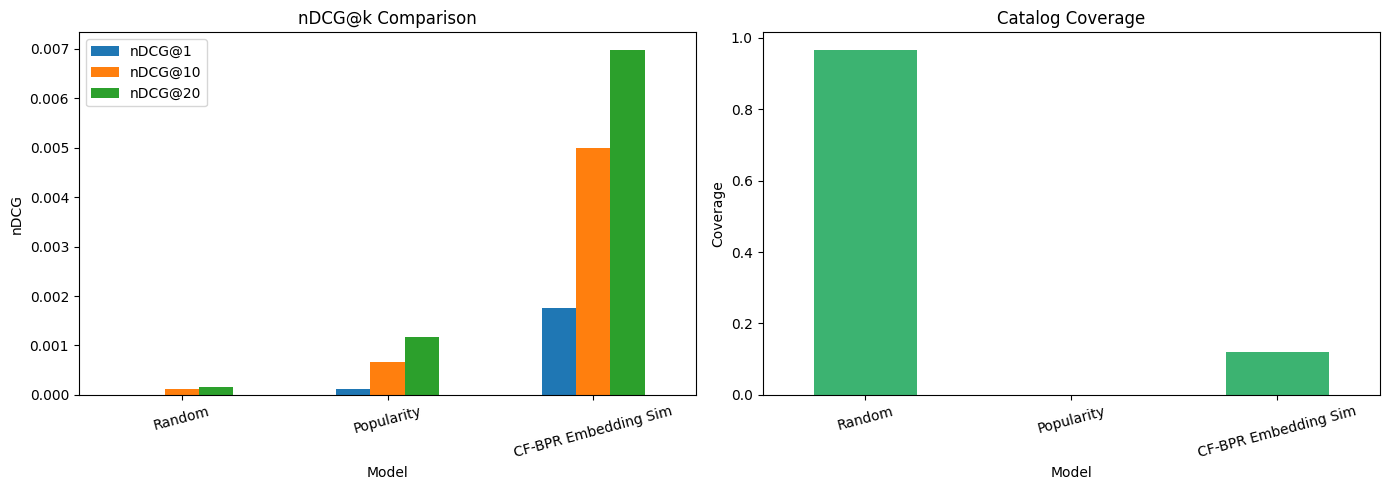

In [9]:
import matplotlib.pyplot as plt

results = pd.DataFrame([r1, r2, r3])
results = results.set_index('Model')
print(results.to_string())

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ndcg_cols = [c for c in results.columns if 'nDCG' in c]
results[ndcg_cols].plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('nDCG@k Comparison')
axes[0].set_ylabel('nDCG')
axes[0].legend(loc='upper left')

results['Coverage'].plot(kind='bar', ax=axes[1], color='mediumseagreen', rot=15)
axes[1].set_title('Catalog Coverage')
axes[1].set_ylabel('Coverage')

plt.tight_layout()
plt.show()

## Key Takeaways

- **Random** gives near-zero nDCG (as expected) but high catalog coverage
- **Popularity** gives zero/low nDCG (same tracks always) and zero coverage
- **CF-BPR** should outperform both by leveraging user listening history embeddings
- **Cold-start users** (no embedding) fall back to popularity — a key challenge

### Next steps:
1. Combine BM25 (text) + CF-BPR (embeddings) for hybrid retrieval
2. Use conversation context (not just user ID) to improve query construction
3. Explore other embedding spaces (audio, lyrics, metadata)
4. Add a re-ranker on top of initial retrieval

---
## 8. Generate Blind-A Submission

Format: one JSON entry per session with `session_id`, `user_id`, `turn_number`, `predicted_track_ids` (up to 20), `predicted_response`.

We predict for the **last user turn that has no music response** in each Blind-A session.

In [10]:
import json, zipfile
from datetime import date

# Load Blind-A
blind_a = pd.read_parquet(DATA_DIR / 'TalkPlayData-Challenge-Blind-A/data/test-00000-of-00001.parquet')
print(f'Blind-A sessions: {len(blind_a)}')

# Find the prediction turn for each session:
# the last user turn that has NO corresponding music turn
blind_a_targets = []
for _, row in blind_a.iterrows():
    turns_with_music = set()
    user_turns = {}  # turn_number -> user content
    for c in row['conversations']:
        if c['role'] == 'music':
            turns_with_music.add(c['turn_number'])
        if c['role'] == 'user':
            user_turns[c['turn_number']] = c['content']
    
    # The turn to predict = user turn without a music response
    predict_turns = sorted(set(user_turns.keys()) - turns_with_music)
    assert len(predict_turns) == 1, f"Expected 1 predict turn, got {predict_turns}"
    tn = predict_turns[0]
    
    blind_a_targets.append({
        'session_id': row['session_id'],
        'user_id': row['user_id'],
        'turn_number': tn,
        'query': user_turns[tn],
    })

blind_a_targets_df = pd.DataFrame(blind_a_targets)
print(f'Prediction targets: {len(blind_a_targets_df)}')
print(f'Turn number distribution:\n{blind_a_targets_df["turn_number"].value_counts().sort_index()}')

Blind-A sessions: 80
Prediction targets: 80
Turn number distribution:
turn_number
1    20
2    15
3    10
4     5
5     8
6     9
7     8
8     5
Name: count, dtype: int64


In [11]:
# Generate predictions using CF-BPR (best baseline) with popularity fallback
# This reuses user_emb_dict, track_emb_matrix, valid_track_ids from above

submission = []
n_cf = 0
n_pop = 0

for _, target in blind_a_targets_df.iterrows():
    uid = target['user_id']
    
    if uid in user_emb_dict:
        user_vec = user_emb_dict[uid].reshape(1, -1)
        sims = cosine_similarity(user_vec, track_emb_matrix)[0]
        top_idx = sims.argsort()[::-1][:TOP_K]
        recs = [valid_track_ids[i] for i in top_idx]
        n_cf += 1
    else:
        # Cold-start: use popularity
        recs = popular_tracks
        n_pop += 1
    
    submission.append({
        'session_id': target['session_id'],
        'user_id': target['user_id'],
        'turn_number': int(target['turn_number']),
        'predicted_track_ids': recs,
        'predicted_response': '',  # no response generation in this baseline
    })

print(f'Generated {len(submission)} predictions (CF: {n_cf}, Popularity fallback: {n_pop})')
print(f'\nSample entry:')
print(json.dumps(submission[0], indent=2)[:300])

Generated 80 predictions (CF: 30, Popularity fallback: 50)

Sample entry:
{
  "session_id": "9c37dcd7-d7c2-4686-8541-1e37c4814a09",
  "user_id": "c3233a5c-da6c-42a3-9459-83ee1134e207",
  "turn_number": 1,
  "predicted_track_ids": [
    "389c8ccb-df4e-42b5-ab44-c96d88559b75",
    "feaebc22-cead-422c-a60b-0200a77f781d",
    "b76c2d30-e541-45fe-9e9b-6fedc8a895e3",
    "3ff67


In [12]:
# Validate submission before saving
track_catalog_ids = set(tracks_df['track_id'])

errors = []
for i, entry in enumerate(submission):
    # Check required keys
    for key in ['session_id', 'user_id', 'turn_number', 'predicted_track_ids', 'predicted_response']:
        if key not in entry:
            errors.append(f'Entry {i}: missing key "{key}"')
    
    # Check track_ids are valid and unique
    tids = entry['predicted_track_ids']
    if len(tids) != len(set(tids)):
        errors.append(f'Entry {i}: duplicate track_ids')
    invalid = [t for t in tids if t not in track_catalog_ids]
    if invalid:
        errors.append(f'Entry {i}: {len(invalid)} invalid track_ids')
    if len(tids) > 20:
        errors.append(f'Entry {i}: {len(tids)} tracks (max 20)')

if errors:
    print(f'VALIDATION FAILED ({len(errors)} errors):')
    for e in errors[:10]:
        print(f'  {e}')
else:
    print(f'Validation passed: {len(submission)} entries, all track_ids valid, no duplicates')

Validation passed: 80 entries, all track_ids valid, no duplicates


In [13]:
# Save submission as JSON + ZIP
SUBMISSIONS_DIR = Path('../submissions')
SUBMISSIONS_DIR.mkdir(exist_ok=True)

today = date.today().isoformat()
json_name = f'blind_a_cf_bpr_baseline_{today}.json'
zip_name = f'blind_a_cf_bpr_baseline_{today}.zip'

json_path = SUBMISSIONS_DIR / json_name
zip_path = SUBMISSIONS_DIR / zip_name

# Write JSON
with open(json_path, 'w') as f:
    json.dump(submission, f, ensure_ascii=False)
print(f'JSON saved: {json_path} ({json_path.stat().st_size / 1024:.1f} KB)')

# Package into ZIP for CodaBench upload
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(json_path, 'prediction.json')
print(f'ZIP saved:  {zip_path} ({zip_path.stat().st_size / 1024:.1f} KB)')

print(f'\n Upload {zip_path.name} to CodaBench for Blind-A evaluation')

JSON saved: ../submissions/blind_a_cf_bpr_baseline_2026-04-19.json (76.2 KB)
ZIP saved:  ../submissions/blind_a_cf_bpr_baseline_2026-04-19.zip (16.7 KB)

 Upload blind_a_cf_bpr_baseline_2026-04-19.zip to CodaBench for Blind-A evaluation
